In [ ]:
!pip install kafka-python msgpack matplotlib tqdm

# Deep Dive 1: Message Keys und Partitioning

**Mein Ziel:** Ich wollte herausfinden, wie ein Message Key aussieht, wie ich ihn optimal gestalten sollte und welchen konkreten Einfluss er auf das Routing-Verhalten meines Kafka-Clusters hat.

**Einleitung:**
Um die Last zu verteilen und mein System horizontal skalierbar zu machen, habe ich in meinem Setup die Topics in mehrere Partitionen unterteilt (konkret `KAFKA_NUM_PARTITIONS: 3`). Wenn mein Producer nun Nachrichten an ein Topic sendet, muss Kafka entscheiden, auf welcher Partition diese landen. 
In diesem Deep Dive habe ich untersucht, wie sich das Routing-Verhalten von Kafka unterscheidet, je nachdem, ob ich definierte Message Keys verwende oder nicht. Besonders wichtig war mir dabei zu verstehen, wie ich die garantierte Reihenfolge (Ordering) meiner Sensordaten sicherstellen kann.

## Szenario A: Das Standardverhalten (Ohne Message Keys)

In meiner ersten Implementierung (Teil 1) habe ich die Sensordaten der Raum-Simulation noch ganz einfach ohne spezifischen Key gesendet:

`producer.send(topic, value=message)`

Da der Key in diesem Fall `empty` (bzw. `None`) war, erwartete ich, dass Kafka standardmässig eine Round-Robin-Strategie (oder den Sticky Partitioner) anwendet. Das heisst, meine produzierten Nachrichten sollten möglichst gleichmässig über alle verfügbaren Partitionen verteilt werden, um die Last auf den Brokern bestmöglich auszugleichen.

**Mein Experiment A:** Um das zu überprüfen, habe ich 1000 generierte Nachrichten ausgelesen und gefiltert. Der folgende Plot zeigt das Resultat: die Verteilung der Nachrichten für einen spezifischen Raum in diesem ersten Szenario:

Warte auf 1000 frische Nachrichten vom Generator...
1000 Nachrichten gesammelt. Erstelle Plot...

Verteilung der Nachrichten für room_10: Counter({1: 28, 0: 28, 2: 11})


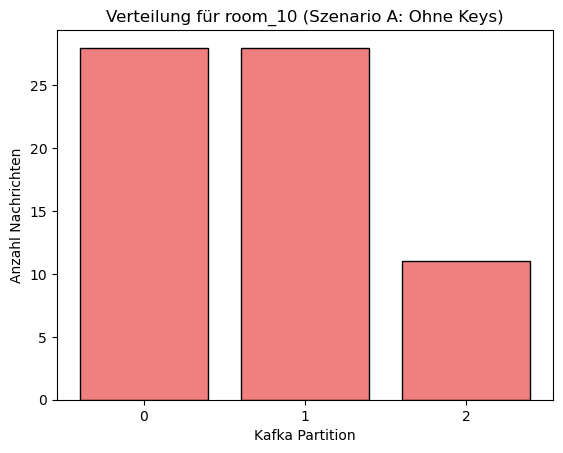

In [7]:
from kafka import KafkaConsumer
import msgpack
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

# 'latest' ich will nur die live generierten Daten lesen!
consumer = KafkaConsumer(
    'room_temperature_mp',
    bootstrap_servers=['kafka1:9092', 'kafka2:9092', 'kafka3:9092'], 
    value_deserializer=lambda m: msgpack.unpackb(m, raw=False),
    auto_offset_reset='latest',  
    consumer_timeout_ms=5000 
)

partition_counts = {}
max_messages = 1000
message_count = 0

print("Warte auf 1000 frische Nachrichten vom Generator...")

with tqdm(total=max_messages, desc="Lese Nachrichten", unit="msg") as pbar:
    for msg in consumer:
        message_count += 1
        partition = msg.partition 
        room_id = msg.value.get('room_id') 
        
        if room_id:
            if room_id not in partition_counts:
                partition_counts[room_id] = []
            partition_counts[room_id].append(partition)
        
        pbar.update(1)
        
        if message_count >= max_messages:
            break

# automatisch den ersten raum nehem
target_room = list(partition_counts.keys())[0] if partition_counts else None

if target_room:
    counts = Counter(partition_counts[target_room])
    print(f"\nVerteilung der Nachrichten für {target_room}: {counts}")

    # Plotting
    plt.bar(counts.keys(), counts.values(), color='lightcoral', edgecolor='black')
    plt.xticks([0, 1, 2])
    plt.xlabel('Kafka Partition')
    plt.ylabel('Anzahl Nachrichten')
    
    plt.title(f'Verteilung für {target_room} (Szenario A: Ohne Keys)')
    plt.show()
else:
    print("Keine Räume gefunden.")

**Meine Beobachtung:** Aus dem Plot konnte ich klar ablesen, dass die Nachrichten eines einzelnen Raumes völlig zufällig über alle drei Partitionen verstreut wurden. 
**Das Problem dabei:** Da Kafka mir die strikte zeitliche Reihenfolge von Nachrichten *nur innerhalb einer einzelnen Partition* garantiert, geht die wichtige Chronologie meiner Sensordaten komplett verloren, sobald ich mehrere Consumer einsetze, die die Partitionen parallel auslesen. Als Resultat könnte beispielsweise ein Temperaturanstieg fälschlicherweise vor einem eigentlich vorher aufgetretenen, niedrigeren Messwert verarbeitet werden – was die Daten unbrauchbar machen würde.

## Szenario B: Gezieltes Partitioning (Mit Message Keys)

Um das Problem der verlorenen Chronologie in den Griff zu bekommen, habe ich meinen Producer-Code angepasst. Ich habe entschieden, jeder Nachricht die eindeutige `room_id` als Message Key mitzugeben:

`producer.send(topic, key=target_room.room_id.encode('utf-8'), value=message)`

Meine Erwartung war folgende: Wenn ein Key vorhanden ist, nutzt Kafka eine Hash-Funktion (`hash(key) % num_partitions`), um die Ziel-Partition zu berechnen. Somit müssten alle Daten eines Raumes auf derselben Partition landen. 

**Mein Experiment B:**
Nach der Anpassung im Code habe ich das Experiment exakt gleich mit 1000 neuen Nachrichten wiederholt. Der Plot zeigt mir nun sehr schön das veränderte Routing-Verhalten:

Warte auf 1000 frische Nachrichten vom Generator...
1000 Nachrichten gesammelt. Erstelle Plot...

Verteilung der Nachrichten für room_11: Counter({1: 67})


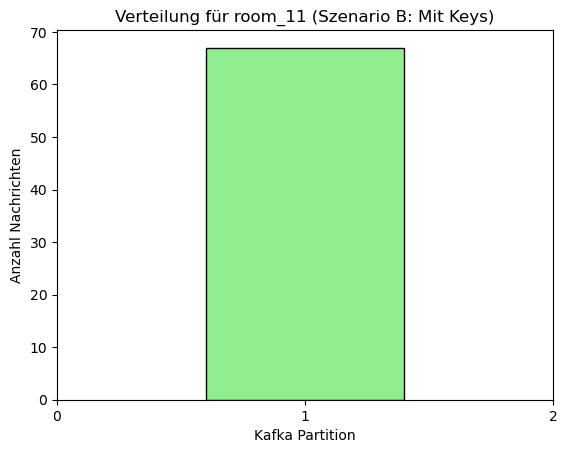

In [8]:
from kafka import KafkaConsumer
import msgpack
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

# 'latest' ich will nur die live generierten Daten lesen!
consumer = KafkaConsumer(
    'room_temperature_mp',
    bootstrap_servers=['kafka1:9092', 'kafka2:9092', 'kafka3:9092'], 
    value_deserializer=lambda m: msgpack.unpackb(m, raw=False),
    auto_offset_reset='latest',  
    consumer_timeout_ms=5000 
)

partition_counts = {}
max_messages = 1000
message_count = 0

print("Warte auf 1000 frische Nachrichten vom Generator...")

with tqdm(total=max_messages, desc="Lese Nachrichten", unit="msg") as pbar:
    for msg in consumer:
        message_count += 1
        partition = msg.partition 
        room_id = msg.value.get('room_id') 
        
        if room_id:
            if room_id not in partition_counts:
                partition_counts[room_id] = []
            partition_counts[room_id].append(partition)
        
        pbar.update(1)  # <-- Fortschrittsbalken um 1 aktualisieren
        
        if message_count >= max_messages:
            break

# automatisch den ersten Raum
target_room = list(partition_counts.keys())[0] if partition_counts else None

if target_room:
    counts = Counter(partition_counts[target_room])
    print(f"\nVerteilung der Nachrichten für {target_room}: {counts}")

    # Plotting
    plt.bar(counts.keys(), counts.values(), color='lightgreen', edgecolor='black')
    plt.xticks([0, 1, 2])
    plt.xlabel('Kafka Partition')
    plt.ylabel('Anzahl Nachrichten')
    
    plt.title(f'Verteilung für {target_room} (Szenario B: Mit Keys)')
    plt.show()
else:
    print("Keine Räume gefunden.")

**Mein Resultat:** Die Anpassung war ein voller Erfolg. Wie ich im Plot sehen kann, landen nun alle Nachrichten für den spezifizierten Raum zu 100 % auf exakt derselben Partition.

## Mein Fazit

Für meine Schul-Simulation hat sich die Einführung eines Message Keys als essenziell herausgestellt. 
Ich finde, dass ein guter Message Key idealerweise ein Attribut sein sollte, das logisch zusammenhängende Ereignisse gruppiert. Für meinen Anwendungsfall ist die `room_id` dafür der absolute perfekte Key. 

Durch das Hashing dieses Keys zwinge ich Kafka jetzt dazu, alle Temperatur-, CO2- und Belegungs-Updates eines spezifischen Raumes konsequent auf dieselbe Partition zu schreiben. So stelle ich sicher, dass mein `Processing Consumer` die Events für einen Raum auch exakt in der Reihenfolge verarbeitet, in der sie in meiner Simulation generiert wurden.

# Deep Dive 2: Consumer Groups und horizontale Skalierung

**Mein Ziel:** In diesem Abschnitt wollte ich praktisch erproben, wie ich Consumer Groups nutzen kann, um die Last meiner Datenverarbeitung horizontal auf mehrere Instanzen zu verteilen (zu skalieren), und beobachten, wie sich mein Kafka-Cluster dabei verhält.

**Einleitung:**
Consumer Groups sind in Kafka genau dafür gedacht, das Lesen von Nachrichten aus einem Topic auf mehrere Instanzen aufzuteilen. Mir war bewusst, dass Kafka dabei strikt garantiert, dass eine Partition immer nur von maximal einem Consumer innerhalb derselben Gruppe gelesen wird. 
Da mein Cluster von Anfang an nicht so konfiguriert war, das es mehrere Partitionen hat, habe ich im nachhinein die `docker-compose` file angepasst mit (`KAFKA_NUM_PARTITIONS: 3`) und somit sollte es bereit für diesen Deep Dive sein.

## Mein Skalierungs-Experiment

Um Kafka's Skalierungs-Feature zu testen, habe ich mich entschieden, meinen `data-processor` (den Processing Consumer), der das Topic `room_environment_mp` ausliest und anreichert, zu skalieren.

**Schritt 1: Vorbereitung meiner Orchestrierung**
Zuerst habe ich in meiner `docker-compose.yaml` den fest vergebenen `container_name` für den `data-processor` Service auskommentiert. Das musste ich tun, da Docker beim Befehl zum Skalieren automatisch dynamische Namen vergeben muss, um Namenskonflikte zu vermeiden.

**Schritt 2: Horizontale Skalierung durchführen**
Anschliessend habe ich den Service über folgenden Docker-Befehl von ursprünglich einer auf drei Instanzen hochskaliert:
`docker compose up -d --scale data-processor=3`

Wie erhofft, starteten dadurch zwei weitere völlig voneinander isolierte Python-Container, die sich allesamt mit exakt derselben `group_id` (`processing_group`) an meinem Kafka-Cluster angemeldet haben.

![3 data processor](images/3-dataprocessors.png)

## Meine Auswertung und der Beweis für das Rebalancing

Um nun live zu überprüfen, wie mein Kafka-Cluster auf die neu hinzugekommenen Consumer reagiert hat, habe ich das offizielle Kafka-CLI-Tool direkt auf dem Broker ausgeführt:
`docker compose exec kafka1 kafka-consumer-groups --bootstrap-server kafka1:9092 --describe --group processing_group`

![Kafka Consumer](images/DeepDive_ConsumerGroups.png)

**Wie ich diese Ergebnisse interpretiere:**
Der abgebildete Output liefert mir den eindeutigen und sichtbaren Beweis für das funktionierende Rebalancing meiner Consumer Group:
* **PARTITION:** Ich sehe, dass das Topic korrekt die Partitionen 0, 1 und 2 besitzt.
* **HOST / CONSUMER-ID:** Ich kann drei verschiedene IP-Adressen (z. B. `/172.18.0.10`, `/172.18.0.11`, `/172.18.0.8`) und drei dazu passende, eindeutige IDs erkennen. Das bestätigt mir erfolgreich, dass meine drei getrennten Docker-Container aktiv arbeiten.
* **Zuweisung:** Das Resultat ist grossartig: Kafka hat meine Last perfekt aufgeteilt. Mein Consumer A liest exklusiv Partition 2, Consumer B liest exklusiv Partition 0 und mein Consumer C liest Partition 1. 
* **LAG:** Der Lag (also die Anzahl der Nachrichten, die momentan noch auf Verarbeitung warten) ist bei allen meinen Consumern minimal (nur 0-2). Das beweist mir abschliessend, dass meine Lastverteilung extrem effizient funktioniert und die erzeugten Datenströme wirklich in Echtzeit abgearbeitet werden.

## Mein Fazit

Durch diesen Deep Dive konnte ich am eigenen System sehen, dass Consumer Groups ein extrem mächtiges Werkzeug zur horizontalen Skalierung sind. 
Wenn ich für zukünftige Ausbaustufen meiner Schul-Simulation die Anzahl der Räume von derzeit 10 auf beispielsweise 10.000 massiv erhöhen würde, würde mein einzelner `data-processor` diese Datenmenge vermutlich nicht mehr rechtzeitig schaffen (mein "Lag" würde exponentiell steigen). 

Dank der Consumer Groups kann ich in so einem Fall ohne eine einzige Code-Änderung einfach weitere Container starten (z.B. per `--scale`). Kafka führt dann wie beobachtet automatisch ein "Rebalancing" durch und verteilt die Partitionen fair auf die neuen Container.
**Eine Limitierung, die ich dabei beachtet habe:** Die maximale Anzahl an effektiven Consumern in meiner Gruppe ist exakt gleich der Anzahl der Partitionen. Hätte ich mein System direkt mit einem vierten Container skaliert, wäre dieser Container in meinem aktuellen Setup "Idle" (bzw. arbeitslos) geblieben, da ich für dieses Topic nur 3 Partitionen eingerichtet habe. Aus diesem praktischen Test erkenne ich, warum die initial gewählte Partitionsanzahl (hier 3) ein extrem wichtiges und zukunftsweisendes Design-Kriterium beim Setup eines jeden Kafka-Clusters ist.

# Deep Dive 3 (Bonus): Offsets und Reprocessing

**Fragestellung:** Wie speichert Kafka den Fortschritt von Consumern und wie kann man alte Daten gezielt neu verarbeiten (Reprocessing)?

**Einleitung:**
Im Gegensatz zu traditionellen Message Queues, bei denen Nachrichten nach dem Konsumieren gelöscht werden, speichert Kafka Daten persistent als Log. Ein Consumer merkt sich lediglich seine aktuelle Leseposition, den sogenannten **Offset**. 
Dieses Architekturmuster ermöglicht "Time Travel": Wenn beispielsweise ein Fehler in der Anreicherungslogik unseres `data-processor` entdeckt und behoben wird, können wir den Offset gezielt zurücksetzen, um historische Daten mit der neuen, korrigierten Logik erneut zu verarbeiten.

## Das Reprocessing-Experiment

Um ein Reprocessing zu erzwingen, wurde die Consumer Group des Processing Consumers manuell manipuliert.

**Schritt 1: Consumer isolieren**
Ein Offset-Reset ist nur möglich, wenn kein Consumer aktiv liest. Daher wurde der Service temporär gestoppt:
`docker compose up -d --scale data-processor=0`

**Schritt 2: Offset Reset erzwingen**
Über das Kafka-CLI-Tool wurde der Offset für das Topic `room_environment_mp` auf den frühestmöglichen Zeitpunkt zurückgesetzt (`--to-earliest`):
`docker compose exec kafka1 kafka-consumer-groups --bootstrap-server kafka1:9092 --group processing_group --topic room_environment_mp --reset-offsets --to-earliest --execute`

![Schritt 2 Deep Dive 3](images/deepdive3_schritt2.png)

## Auswertung: Der "Lag" als Indikator

Unmittelbar nach dem Zurücksetzen wurde der Status der Consumer Group abgefragt, um die Auswirkungen zu verifizieren:

![LAG anezeigen](images/deepdive3_schritt2.5_LAG-ansicht.png)
---
![Schritt 3 Deep Dive 3](images/deepdive3_schritt3.png)

**Interpretation der Ergebnisse:**
Der Output zeigt eindrücklich das Prinzip von Offsets in Kafka:
* **CURRENT-OFFSET:** Wurde auf `0` (bzw. den Startwert der Retention) zurückgesetzt. Das ist die Position, an der die Consumer Group weiterlesen wird.
* **LOG-END-OFFSET:** Bleibt hoch, da die eigentlichen Daten im Topic durch den Reset nicht gelöscht oder angetastet wurden.
* **LAG:** Der Lag repräsentiert die Differenz (Rückstand). Er ist nun massiv angestiegen, was bedeutet, dass tausende Nachrichten auf die erneute Verarbeitung warten.

Als der `data-processor` anschliessend wieder auf eine Instanz hochskaliert wurde (`--scale data-processor=1`), verarbeitete er den gesamten Lag in Höchstgeschwindigkeit, bis er wieder bei den Echtzeit-Daten (Lag ~ 0) ankam.

## kurzes Fazit | zweites Experiment

Das zeigt mir das es die messages die im LAG sehr schnell wieder bearbeitet hat nachdem ich den `data-processors` wieder gestartet habe. Dies könnte hilfreich sein wenn man später für die Schule ein Machine-Learning-Modell entwickeln will, das Muster für schelchte Luftqualität besser erkennt, kann man einfach eine neue Consumer Group erstellen (die bei Offset 0 startet) und das Modell mit allen historischen Sensordatne der letzte Monate trainieren. 

Aber ich will irgendwie noch eine Parktische Anwendung sehen. Zum Beispiel mit dem `data-sink`. Wenn ich das richtig verstanden habe, sollte somit auch möglich sein die `.csv` Dateien "wiederherzustellen".

Dieses Experiment versuchen ich nun:

Zuerst stoppe ich den `data-sink` container mit:

`docker compose stop data-sink`

Und zugleich lösche ich die alten Daten von `data`.

`rm data/alerts_log.csv` und `rm data/temperature_log.csv`

![Zweites Experiment Deep Dive 2_3](images/deepdive4_schritt1.png)

Und nun muss ich auch die Offsets von `Alerts` und `Temperature` zurücksetzen. Dass kann ich mit diesen Befehlen ausführen:

`docker compose exec kafka1 kafka-consumer-groups --bootstrap-server kafka1:9092 --group sink_alerts_group_mp --topic room_alerts_mp --reset-offsets --to-earliest --execute`

`docker compose exec kafka1 kafka-consumer-groups --bootstrap-server kafka1:9092 --group sink_temp_group_mp --topic room_temperature_mp --reset-offsets --to-earliest --execute`

und die Offset sind wieder zurückgesetzt:

![Offset zurücksetzen](images/deepdive4_schritt2.png)

Nun starte ich den `data-sink` Container wieder neu. Und man sieht mit dem Befehl `wc -l data/temperature_log.csv` (wordcount lines) sehr schnell als Beweis wie die Zahl der Wörter in die Höhe schiesst.

![Data Sink restart](images/deepdive4_schritt3.png)

Man sieht sofort nach dem Neustart des `data-sink` Containers begannen die Consumer, den massiven Lag abzuarbeiten.

Mit diesem Experiment habe ich eindrücklich bewiesen, dass Kafka nicht nur ein Nachrichtentransporter ist, sondern als robuste, persistente Event-Source-Datenbank agieren kann. 